# Hospital Bed Capacity Analytics
### A data-driven approach to reducing hospital bed congestion in Australia

**Business question:** Which hospital case types (AR-DRGs) drive the most bed demand, and how much capacity and cost could be recovered by improving length of stay for the highest-burden cases?

Data: AIHW Australian Refined Diagnosis Related Groups (AR-DRG) Data Cube, 2023-24 (national admitted patient activity).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## 1. Data Preparation

Load the AR-DRG data cube, standardise column names, and remove non-data artefacts (e.g. a repeated header row embedded in the raw spreadsheet).

In [2]:
df = pd.read_excel("ar-drg_2023-24_aihw.xlsx")

df = df.rename(columns={
    "MDC V11.0": "MDC",
    "DRG Partition": "DRG_Partition",
    "DRG V11.0": "DRG",
    "Age Group": "Age_Group",
    "Sex": "Sex",
    "Same-day Flag": "Same_Day",
    "Separations": "Separations",
    "Patient Days": "Patient_Days",
})

# Drop a repeated header row embedded inside the sheet
df = df[df["MDC"] != "MDC V11.0"]

df["Separations"] = pd.to_numeric(df["Separations"], errors="coerce")
df["Patient_Days"] = pd.to_numeric(df["Patient_Days"], errors="coerce")
df = df.dropna(subset=["Separations", "Patient_Days"])
df = df[df["Separations"] > 0]

df["ALOS"] = df["Patient_Days"] / df["Separations"]

print(f"Rows after cleaning: {len(df):,}")
print(f"Unique DRGs: {df['DRG'].nunique()}")
df.head()

Rows after cleaning: 44,513
Unique DRGs: 799


,MDC,DRG_Partition,DRG,Age_Group,Sex,Same_Day,Separations,Patient_Days,ALOS
0,MDC 00 Pre MDC,1- Intervention,"A13A Ventilation >= 336 Hours, Major Complexity",01- Age under 1,1- Male,2- Overnight,8,604,75.50
1,MDC 00 Pre MDC,1- Intervention,"A13A Ventilation >= 336 Hours, Major Complexity",01- Age under 1,2- Female,2- Overnight,5,494,98.80
2,MDC 00 Pre MDC,1- Intervention,"A13A Ventilation >= 336 Hours, Major Complexity",02- Age 1-4 yrs,1- Male,2- Overnight,6,448,74.67
3,MDC 00 Pre MDC,1- Intervention,"A13A Ventilation >= 336 Hours, Major Complexity",02- Age 1-4 yrs,2- Female,2- Overnight,2,138,69.00
4,MDC 00 Pre MDC,1- Intervention,"A13A Ventilation >= 336 Hours, Major Complexity",03- Age 5-9 yrs,1- Male,2- Overnight,4,466,116.50


## 2. Exploratory Analysis: Where Is the Bed Demand Coming From?

Total patient-days is the true measure of bed occupancy load. A small number of DRGs and older age groups are expected to dominate national demand.

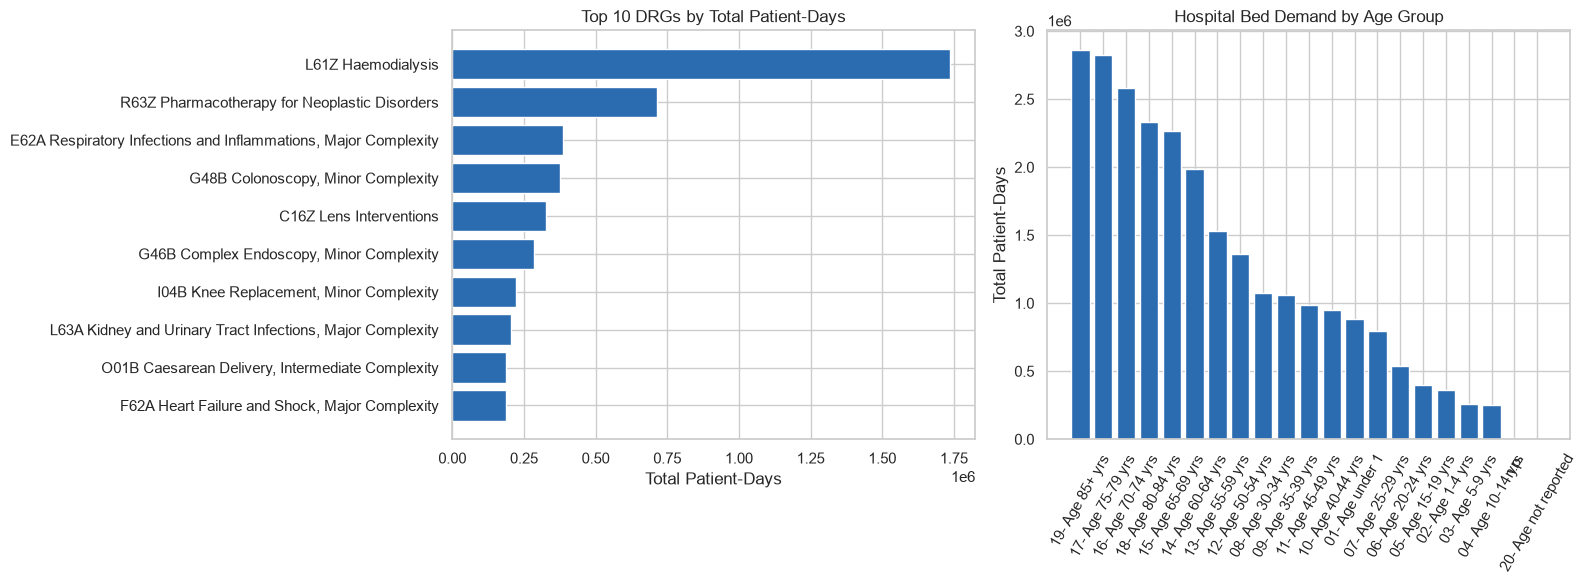

In [3]:
top10_drg = df.groupby("DRG")["Patient_Days"].sum().sort_values(ascending=False).head(10)
age_use = df.groupby("Age_Group")["Patient_Days"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10_drg.index[::-1], top10_drg.values[::-1], color="#2b6cb0")
axes[0].set_title("Top 10 DRGs by Total Patient-Days")
axes[0].set_xlabel("Total Patient-Days")

axes[1].bar(age_use.index, age_use.values, color="#2b6cb0")
axes[1].set_title("Hospital Bed Demand by Age Group")
axes[1].set_ylabel("Total Patient-Days")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.savefig("images/top_drgs_and_age_groups.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
overall_alos = df["Patient_Days"].sum() / df["Separations"].sum()
total_patient_days = df["Patient_Days"].sum()
total_separations = df["Separations"].sum()

print(f"Total patient-days (national, 2023-24): {total_patient_days:,.0f}")
print(f"Total separations (admissions): {total_separations:,.0f}")
print(f"System-wide average length of stay: {overall_alos:.2f} days")

Total patient-days (national, 2023-24): 25,321,389
Total separations (admissions): 11,612,052
System-wide average length of stay: 2.18 days


## 3. Predictive Model: Forecasting Average Length of Stay (ALOS)

ALOS is the key lever for bed capacity: for a fixed number of admissions, a shorter average stay frees up beds faster. The model predicts ALOS from case classification (DRG), age group, and DRG partition (intervention vs. medical), so that hospitals can forecast bed demand for any patient segment before it happens.

Data is aggregated to **DRG x Age Group x DRG Partition** level (rather than left at the raw record level) to produce stable, planning-relevant estimates rather than noisy single-patient variation. Segments with fewer than 10 separations are excluded as statistically unreliable.

In [5]:
model_df = (
    df.groupby(["DRG", "Age_Group", "DRG_Partition"])[["Patient_Days", "Separations"]]
      .sum()
      .reset_index()
)
model_df["ALOS"] = model_df["Patient_Days"] / model_df["Separations"]
model_df = model_df[model_df["Separations"] >= 10].copy()

print(f"Modelling dataset: {len(model_df):,} DRG x Age Group segments")

Modelling dataset: 11,902 DRG x Age Group segments


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES = ["DRG", "Age_Group", "DRG_Partition"]
X = model_df[FEATURES]
y = model_df["ALOS"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES)
    ])),
    ("regressor", LinearRegression()),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
error_reduction = (baseline_mae - mae) / baseline_mae

print(f"Model R-squared:            {r2:.3f}")
print(f"Model MAE (days):           {mae:.2f}")
print(f"Model RMSE (days):          {rmse:.2f}")
print(f"Naive baseline MAE (days):  {baseline_mae:.2f}")
print(f"Error reduction vs. naive baseline: {error_reduction:.0%}")

Model R-squared:            0.855
Model MAE (days):           1.17
Model RMSE (days):          2.61
Naive baseline MAE (days):  4.58
Error reduction vs. naive baseline: 74%


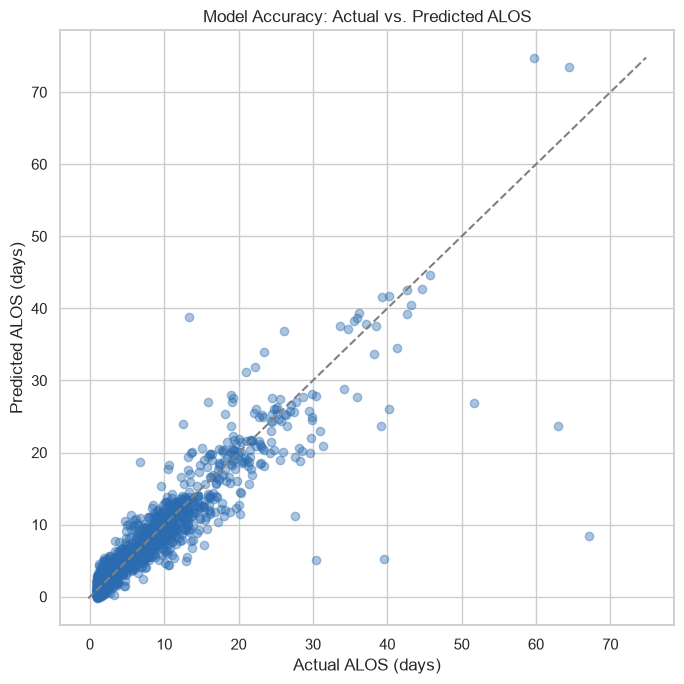

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.4, color="#2b6cb0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, linestyle="--", color="gray")
ax.set_title("Model Accuracy: Actual vs. Predicted ALOS")
ax.set_xlabel("Actual ALOS (days)")
ax.set_ylabel("Predicted ALOS (days)")
plt.tight_layout()
plt.savefig("images/actual_vs_predicted_alos.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this chart:** points sitting close to the dashed line are segments the model predicts well. The tight clustering around the line for the bulk of segments is consistent with the R² above — the model explains the large majority of variation in length of stay from case type, age and partition alone.

## 4. From Predicted ALOS to Bed Demand

Multiplying predicted ALOS by separations converts a length-of-stay forecast into an expected number of occupied bed-days per segment — the metric hospital capacity planners actually manage against.

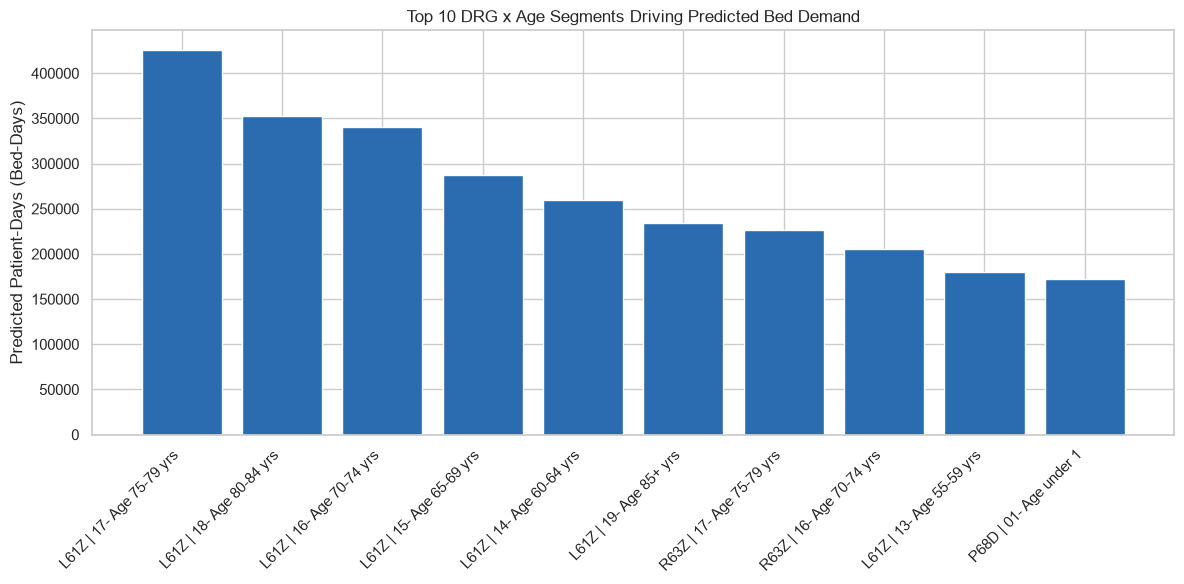

,DRG,Age_Group,Separations,Pred_ALOS,Pred_Patient_Days
9860,L61Z Haemodialysis,17- Age 75-79 yrs,232863,1.83,"426,059.89"
9861,L61Z Haemodialysis,18- Age 80-84 yrs,170023,2.07,"352,673.12"
9859,L61Z Haemodialysis,16- Age 70-74 yrs,217419,1.57,"340,333.32"
9858,L61Z Haemodialysis,15- Age 65-69 yrs,212441,1.35,"287,331.61"
9857,L61Z Haemodialysis,14- Age 60-64 yrs,210018,1.24,"259,444.77"
9862,L61Z Haemodialysis,19- Age 85+ yrs,91838,2.56,"234,671.41"
11736,R63Z Pharmacotherapy for Neoplastic Disorders,17- Age 75-79 yrs,105454,2.14,"226,177.59"
11735,R63Z Pharmacotherapy for Neoplastic Disorders,16- Age 70-74 yrs,109121,1.88,"205,199.14"
9856,L61Z Haemodialysis,13- Age 55-59 yrs,169166,1.06,"179,825.76"
11101,"P68D Neonate, Admission Weight >= 2500g withou...",01- Age under 1,33719,5.09,"171,763.02"


In [8]:
model_df["Pred_ALOS"] = model.predict(model_df[FEATURES]).clip(min=0)
model_df["Pred_Patient_Days"] = model_df["Separations"] * model_df["Pred_ALOS"]

top10_segments = model_df.sort_values("Pred_Patient_Days", ascending=False).head(10).copy()
top10_segments["Label"] = top10_segments["DRG"].str.slice(0, 4) + " | " + top10_segments["Age_Group"]

plt.figure(figsize=(12, 6))
plt.bar(top10_segments["Label"], top10_segments["Pred_Patient_Days"], color="#2b6cb0")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 DRG x Age Segments Driving Predicted Bed Demand")
plt.ylabel("Predicted Patient-Days (Bed-Days)")
plt.tight_layout()
plt.savefig("images/top_segments_bed_demand.png", dpi=150, bbox_inches="tight")
plt.show()

top10_segments[["DRG", "Age_Group", "Separations", "Pred_ALOS", "Pred_Patient_Days"]]

Consistent with the wider AIHW reporting, **haemodialysis (L61Z)** and **pharmacotherapy for neoplastic disorders (R63Z)** stand out as the largest single contributors to predicted bed demand, concentrated in older age groups.

## 5. Scenario Analysis: "What If We Reduce Length of Stay?"

Rather than a system-wide initiative, this models a **targeted intervention**: improving discharge and care efficiency for the 50 highest-burden DRG x Age segments (by predicted bed-days) — the segments where a small improvement has the largest system-wide payoff.

For each segment, the scenario reduces predicted ALOS by 5% and 10%, holding admission volumes constant, and re-computes bed-days.

**Cost-per-bed-day is a modelled assumption, not an observed value.** Reported Australian benchmarks vary by jurisdiction and care intensity:

| Source | Estimated cost per bed-day (AUD) |
|---|---|
| NSW Health (2024), average public hospital bed | ~$1,075 |
| WA Audit Commission (2022), average public hospital bed | ~$2,370 |
| Hicks (2019), ICU bed-day (high-acuity care) | ~$4,375-$4,875 |

This analysis uses **$2,500/bed-day** as a central planning assumption (in line with the WA benchmark), and the $ figures below should be read as an order-of-magnitude business case, not an audited financial forecast — the bed-days-saved figures are the more robust output of the model, since they don't depend on a cost assumption at all.

In [9]:
TOP_N = 50
REDUCTION_SCENARIOS = [0.05, 0.10]
COST_PER_BED_DAY = 2500  # AUD, central planning assumption (see benchmark table above)

focus = model_df.sort_values("Pred_Patient_Days", ascending=False).head(TOP_N).copy()

scenario_rows = []
for reduction in REDUCTION_SCENARIOS:
    scenario_patient_days = focus["Separations"] * (focus["Pred_ALOS"] * (1 - reduction))
    bed_days_saved = (focus["Pred_Patient_Days"] - scenario_patient_days).sum()
    scenario_rows.append({
        "ALOS reduction": f"{int(reduction*100)}%",
        "Bed-days saved (top 50 segments)": round(bed_days_saved),
        "Beds freed per day (avg.)": round(bed_days_saved / 365, 1),
        "Estimated cost avoided (AUD, @ $2,500/day)": round(bed_days_saved * COST_PER_BED_DAY),
    })

scenario_summary = pd.DataFrame(scenario_rows)
scenario_summary

,ALOS reduction,Bed-days saved (top 50 segments),Beds freed per day (avg.),"Estimated cost avoided (AUD, @ $2,500/day)"
0,5%,286764,785.70,716910587
1,10%,573528,"1,571.30",1433821175


## 6. Executive Summary

The table below is the headline output of the model — the numbers a hospital operations manager would actually take into a planning meeting.

In [10]:
headline = scenario_summary.iloc[-1]  # 10% scenario

executive_summary = pd.DataFrame({
    "Metric": [
        "Model accuracy (R-squared)",
        "Model error (MAE, days)",
        "Error reduction vs. naive baseline",
        "Segments in scope (highest-burden DRG x Age groups)",
        "Bed-days saved per year (10% ALOS reduction)",
        "Beds freed per day (avg., 10% scenario)",
        "Estimated annual cost avoided (10% scenario, @ $2,500/bed-day)",
    ],
    "Value": [
        f"{r2:.3f}",
        f"{mae:.2f}",
        f"{error_reduction:.0%}",
        f"{TOP_N}",
        f"{headline['Bed-days saved (top 50 segments)']:,.0f}",
        f"{headline['Beds freed per day (avg.)']:,.1f}",
        f"${headline['Estimated cost avoided (AUD, @ $2,500/day)']:,.0f}",
    ],
})
executive_summary

,Metric,Value
0,Model accuracy (R-squared),0.855
1,"Model error (MAE, days)",1.17
2,Error reduction vs. naive baseline,74%
3,Segments in scope (highest-burden DRG x Age gr...,50
4,Bed-days saved per year (10% ALOS reduction),"573,528"
5,"Beds freed per day (avg., 10% scenario)","1,571.3"
6,"Estimated annual cost avoided (10% scenario, @...","$1,433,821,175"


In [11]:
dashboard_export = focus[["DRG", "Age_Group", "DRG_Partition", "Separations", "Pred_ALOS", "Pred_Patient_Days"]].copy()
dashboard_export["Scenario_ALOS_10pct"] = focus["Pred_ALOS"] * 0.90
dashboard_export["Bed_Days_Saved_10pct"] = focus["Pred_Patient_Days"] - focus["Separations"] * dashboard_export["Scenario_ALOS_10pct"]
dashboard_export = dashboard_export.sort_values("Bed_Days_Saved_10pct", ascending=False)
dashboard_export.to_csv("hospital_capacity_dashboard_export.csv", index=False)
print("Exported: hospital_capacity_dashboard_export.csv (feeds the Power BI dashboard)")
dashboard_export.head(10)

Exported: hospital_capacity_dashboard_export.csv (feeds the Power BI dashboard)


,DRG,Age_Group,DRG_Partition,Separations,Pred_ALOS,Pred_Patient_Days,Scenario_ALOS_10pct,Bed_Days_Saved_10pct
9860,L61Z Haemodialysis,17- Age 75-79 yrs,2- Medical,232863,1.83,"426,059.89",1.65,"42,605.99"
9861,L61Z Haemodialysis,18- Age 80-84 yrs,2- Medical,170023,2.07,"352,673.12",1.87,"35,267.31"
9859,L61Z Haemodialysis,16- Age 70-74 yrs,2- Medical,217419,1.57,"340,333.32",1.41,"34,033.33"
9858,L61Z Haemodialysis,15- Age 65-69 yrs,2- Medical,212441,1.35,"287,331.61",1.22,"28,733.16"
9857,L61Z Haemodialysis,14- Age 60-64 yrs,2- Medical,210018,1.24,"259,444.77",1.11,"25,944.48"
9862,L61Z Haemodialysis,19- Age 85+ yrs,2- Medical,91838,2.56,"234,671.41",2.30,"23,467.14"
11736,R63Z Pharmacotherapy for Neoplastic Disorders,17- Age 75-79 yrs,2- Medical,105454,2.14,"226,177.59",1.93,"22,617.76"
11735,R63Z Pharmacotherapy for Neoplastic Disorders,16- Age 70-74 yrs,2- Medical,109121,1.88,"205,199.14",1.69,"20,519.91"
9856,L61Z Haemodialysis,13- Age 55-59 yrs,2- Medical,169166,1.06,"179,825.76",0.96,"17,982.58"
11101,"P68D Neonate, Admission Weight >= 2500g withou...",01- Age under 1,2- Medical,33719,5.09,"171,763.02",4.58,"17,176.30"


## 7. Business Recommendations

1. **Target haemodialysis (L61Z) and neoplastic pharmacotherapy (R63Z) first.** These two DRGs alone account for a disproportionate share of predicted bed-days — a targeted discharge-planning and care-pathway review here has more leverage than a system-wide policy change.
2. **Use predicted ALOS as an early-warning capacity signal.** Because the model explains roughly 85% of ALOS variation from case type, age and partition alone (see R-squared above), hospitals can forecast bed pressure for a patient segment before occupancy data confirms it.
3. **Treat the $-savings figure as a planning range, not a forecast.** Report the 5% and 10% scenarios together with the cited cost-per-bed-day range (NSW/WA/ICU benchmarks) so decision-makers see the sensitivity, not a single number.
4. **Re-run this model each AIHW data cube release.** ALOS drivers shift with case mix and population ageing; a one-off model will decay in accuracy.

## 8. Limitations

- **Single year of data (2023-24).** The model has not been validated against prior years, so it captures a snapshot rather than a trend.
- **Linear regression is intentionally simple.** It was chosen for transparency and interpretability over a small accuracy gain from a more complex model — appropriate for a first capacity-planning tool, but a non-linear model (e.g. gradient boosting) could improve accuracy further.
- **Cost-per-bed-day is an assumption, not hospital-specific accounting data.** Actual savings will vary by jurisdiction, hospital type, and how freed capacity is actually used (e.g. reduced overtime vs. additional elective admissions).
- **The scenario holds admission volume constant.** It does not model second-order effects, such as freed beds being immediately backfilled by demand growth.